# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from typing import Optional

from enum import Enum
from datetime import datetime

import random
import numpy as np
import os
import pickle

from braket.circuits import Circuit, gates
from braket.tracking import Tracker

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.providers import Backend
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.transpiler.passes import RemoveBarriers

from qiskit_braket_provider import (
    BraketLocalBackend,
    BraketProvider,
    to_braket,
    to_qiskit
)


DATA_PATH = os.path.join("data")

# Use Braket SDK Cost Tracking to estimate the cost to run this example
tracker = Tracker().start()

## Noise models

In [2]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.

    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model

In [3]:
def bitflip_model(p: float) -> NoiseModel:
    """Bitflip noise model with majority vote approach.

    Args:
        p: Probability to flip.
    Returns:
        Bit-flip noise model.
    """
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
    error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

## Constants

In [4]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3


# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [5]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
# ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
# BETA = np.deg2rad(175)
ANGLES = {PEEK: np.deg2rad(40), REVERSE_1: np.deg2rad(230), REVERSE_2: np.deg2rad(310)}
BETA = np.deg2rad(220)

## Expectation values

In [6]:
def decode_results(results: dict, charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1

            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")

                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]

    return decoded_results

In [7]:
def double_expect(settings: tuple[int, int], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)

## State preparation

In [8]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [9]:
def cnot_ladder(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

In [10]:
def cnot_ladder_random(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard) for random strategy."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [11]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)


def apply_setting(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  angle: float, 
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)
        elif strategy == "random":
            cnot_ladder_random(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)

        if observer is BOB:
            qc.h(BOB)
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)


def apply_measurement(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    if setting is PEEK:
        if strategy == "majority_vote":
            # Ask friend for the outcome.
            qc.measure(friend_qubits, observer_creg)
        elif strategy == "random":
            random_offset = random.randint(0, friend_size - 1)
            qc.measure(friend_qubits[0] + random_offset, observer)
    elif setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            qc.measure(observer, observer_creg)
        elif strategy == "random":
            qc.measure(observer, observer)


def ewfs(alice_setting: int,
         bob_setting: int,
         strategy: str,
         angles: list[float],
         beta: float,
         charlie_size: int,
         debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice's qubit", "Bob's qubit", "Charlie", "Debbie"])
    ]

    if strategy == "majority_vote":
        if (alice_setting == PEEK and bob_setting != PEEK):
            measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
            alice_creg = list(range(charlie_size))
            bob_creg = charlie_size
        else:
            measurement = ClassicalRegister(meas_size, name="Measurement")
            alice_creg = 0
            bob_creg = 1
    elif strategy == "random":
        measurement = ClassicalRegister(sys_size, name="Measurement")
        alice_creg, bob_creg = 0, 0
    else:
        raise ValueError(f"Strategy: {strategy} is not defined.")

    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = list(range(sys_size, (sys_size + charlie_size)))
    debbie_qubits = list(range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size)))

    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)

    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    if strategy == "majority_vote":
        cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
        cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)
    elif strategy == "random":
        cnot_ladder_random(qc, ALICE, charlie_qubits[0], charlie_size)
        cnot_ladder_random(qc, BOB, debbie_qubits[0], debbie_size)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, strategy, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, strategy, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    apply_measurement(qc, strategy, ALICE, alice_setting, alice_creg, charlie_qubits, charlie_size)
    apply_measurement(qc, strategy, BOB, bob_setting, bob_creg, debbie_qubits, debbie_size)

    return qc

## Sanity checks (for majority vote approach)

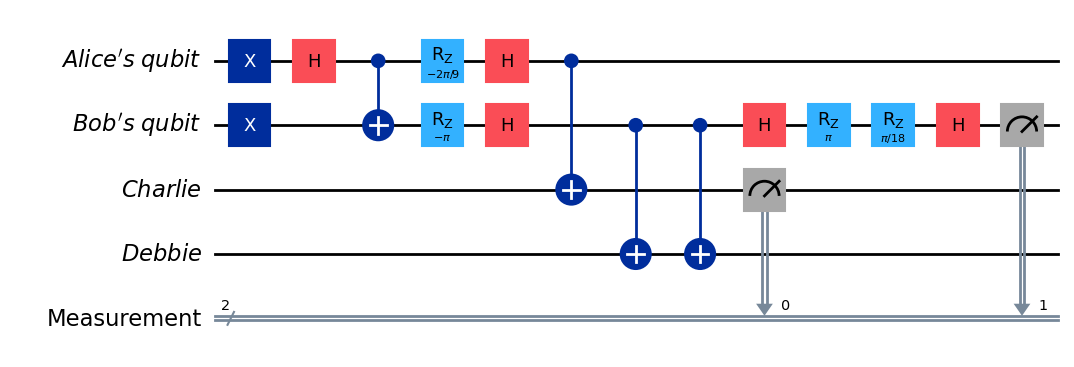

In [12]:
# Print example circuit.
charlie_size = 1
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)

qc.draw("mpl", style="default")#.savefig("ewfs_majority_vote_peek_reverse_1.pdf")

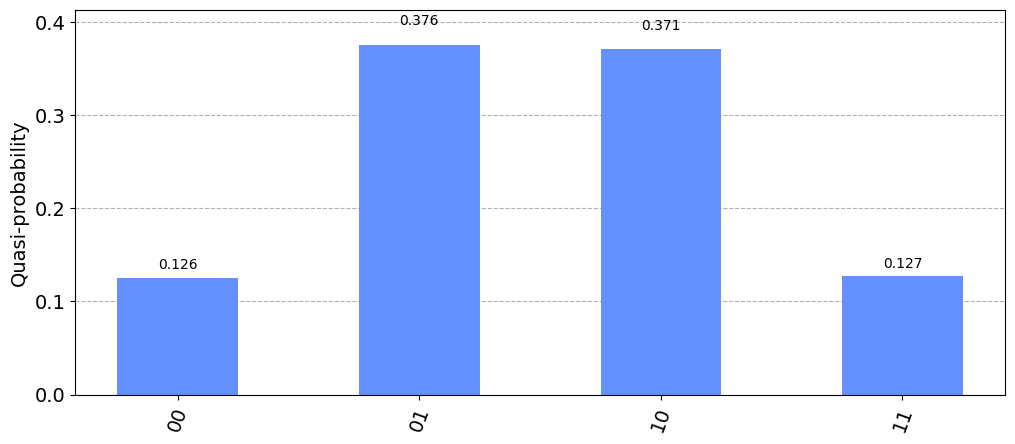

In [13]:
noise_bit_flip = bitflip_model(0.03)
simulator = AerSimulator(noise_model=noise_bit_flip)
transpiled_qc = transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

job = simulator.run(transpiled_qc, shots=10000)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / 10000 for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

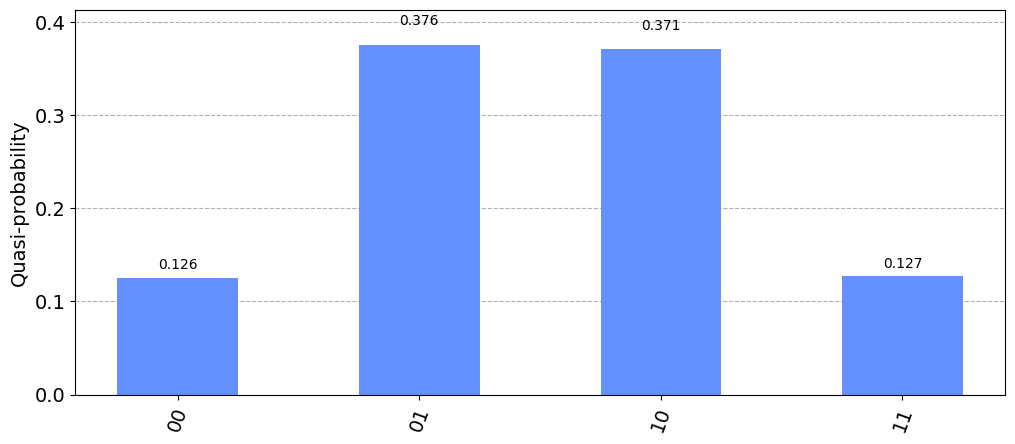

In [14]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

## Branch factor

In [15]:
# TODO: This needs to be more general.
def calculate_branch_factor(friend_size: int) -> float:
    return friend_size - 1

## File I/O

In [16]:
def save_data(
    results: dict,
    backend: Backend,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    backend_name: Optional[str] = None,
    data_path: str = DATA_PATH,
):
    """Writes data to a file name format of `<MACHINE_NAME>_qubits_<NUM_QUBITS>_trial_<NUM_TRIALS>_shots_<NUM_SHOTS>`."""
    if backend_name is None:
        backend_name = backend.name

    for friend_size in friend_sizes:
        qubits = friend_size

        # If not output file name is given, use this format.
        output_file_name = f"{backend_name}_qubits_{qubits}_trial_{num_trials}_shots_{shots}.pickle"
        output_path = os.path.join(data_path, output_file_name)

        print(f"Writing data to: {output_path}")
        with open(output_path, "wb") as handle:
            pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [17]:
def load_experiments(
    machine_name: str,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    strategy: str,
    data_path: str = DATA_PATH,
) -> dict:
    """Load experiments from multiple files."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        for trial in range(1, num_trials+1):
            with open(os.path.join(data_path, f"{machine_name}_qubits_{friend_size}_trial_{trial}_shots_{shots}.pickle"), "rb") as file:
                results = pickle.load(file)
            violations = compute_violations(results=results, charlie_size=friend_size, debbie_size=1, strategy=strategy)
            for key in violations:
                all_results[friend_size][key].append(violations[key])
    return all_results

## Inequalities

In [18]:
def compute_inequalities(results, verbose=False) -> dict[str, float]:
    """Compute the semi-Brukner inequalities."""
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)

    # Eq. (18) from arXiv:1907.05607.
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")

    return {"semi_brukner": semi_brukner}

In [19]:
def compute_violations(results: dict, charlie_size: int, debbie_size: int, strategy: str, verbose: bool = False) -> dict[str, float]:
    """Compute violation values based on strategy."""
    if strategy == "random":
        return compute_inequalities(results=results, verbose=verbose)
    elif strategy == "majority_vote":
        return compute_inequalities(decode_results(results=results, charlie_size=charlie_size, debbie_size=debbie_size), verbose=verbose)
    raise ValueError(f"Strategy: {strategy} not defined.")

### Calculations for Device

In [20]:
def count_gates(qc: QuantumCircuit) -> int:
    gate_counts = {"single_qubit_gates": 0, "two_qubit_gates": 0}
    for instr, qargs, _ in qc.data:
        if isinstance(instr, qiskit.circuit.Gate):
            if len(qargs) == 1:
                gate_counts["single_qubit_gates"] += 1
            elif len(qargs) == 2:
                gate_counts["two_qubit_gates"] += 1
    return gate_counts

In [21]:
strategy = "majority_vote"
all_experiment_combos = [
    [PEEK, REVERSE_1],
    [PEEK, REVERSE_2],
    [REVERSE_2, REVERSE_1],
    [REVERSE_2, REVERSE_2]
]
circuits = {}

num_qubits = 5
for charlie_size in range(1, num_qubits):
    print(f"Charlie size: {charlie_size}")
    for alice, bob in all_experiment_combos:
        qc = ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)
        gate_counts = count_gates(qc)
        print(f"Alice:{alice}, Bob:{bob}, {gate_counts}")

Charlie size: 1
Alice:1, Bob:2, {'single_qubit_gates': 11, 'two_qubit_gates': 4}
Alice:1, Bob:3, {'single_qubit_gates': 11, 'two_qubit_gates': 4}
Alice:3, Bob:2, {'single_qubit_gates': 15, 'two_qubit_gates': 5}
Alice:3, Bob:3, {'single_qubit_gates': 15, 'two_qubit_gates': 5}
Charlie size: 2
Alice:1, Bob:2, {'single_qubit_gates': 11, 'two_qubit_gates': 5}
Alice:1, Bob:3, {'single_qubit_gates': 11, 'two_qubit_gates': 5}
Alice:3, Bob:2, {'single_qubit_gates': 15, 'two_qubit_gates': 7}
Alice:3, Bob:3, {'single_qubit_gates': 15, 'two_qubit_gates': 7}
Charlie size: 3
Alice:1, Bob:2, {'single_qubit_gates': 11, 'two_qubit_gates': 6}
Alice:1, Bob:3, {'single_qubit_gates': 11, 'two_qubit_gates': 6}
Alice:3, Bob:2, {'single_qubit_gates': 15, 'two_qubit_gates': 9}
Alice:3, Bob:3, {'single_qubit_gates': 15, 'two_qubit_gates': 9}
Charlie size: 4
Alice:1, Bob:2, {'single_qubit_gates': 11, 'two_qubit_gates': 7}
Alice:1, Bob:3, {'single_qubit_gates': 11, 'two_qubit_gates': 7}
Alice:3, Bob:2, {'single_q

## Compilation

In [22]:
def compile_to_ionq_gateset(circuit: Circuit) -> Circuit:
    compiled = Circuit()

    for instr in circuit.instructions:
        if isinstance(instr.operator, gates.Vi):
            compiled.add_instruction(gates.Instruction(gates.Rx(-np.pi / 2), instr.target))
        elif isinstance(instr.operator, gates.V):
            compiled.add_instruction(gates.Instruction(gates.Rx(np.pi / 2), instr.target))
        elif isinstance(instr.operator, gates.Ry):
            compiled.add_instruction(gates.Instruction(gates.Rx(-np.pi / 2), instr.target))
            compiled.add_instruction(gates.Instruction(gates.Rz(-instr.operator.angle), instr.target))
            compiled.add_instruction(gates.Instruction(gates.Rx(np.pi / 2), instr.target))
        elif isinstance(instr.operator, gates.Y):
            compiled.add_instruction(gates.Instruction(gates.Rx(-np.pi / 2), instr.target))
            compiled.add_instruction(gates.Instruction(gates.Rz(np.pi), instr.target))
            compiled.add_instruction(gates.Instruction(gates.Rx(np.pi / 2), instr.target))
        elif isinstance(instr.operator, gates.X):
            compiled.add_instruction(gates.Instruction(gates.Rx(np.pi), instr.target))
        elif isinstance(instr.operator, gates.Z):
            compiled.add_instruction(gates.Instruction(gates.Rz(np.pi), instr.target))
        elif isinstance(instr.operator, gates.S):
            compiled.add_instruction(gates.Instruction(gates.Rz(np.pi / 2), instr.target))
        elif isinstance(instr.operator, gates.Si):
            compiled.add_instruction(gates.Instruction(gates.Rz(-np.pi / 2), instr.target))
        else:
            compiled.add_instruction(instr)

    return compiled

## Experiment

#### Settings

In [23]:
# Experimental settings:
shots = 10_000
num_trials = 1
friend_sizes = range(1, 4)
strategy = "random"
save = False

# Backend settings:
backend = BraketLocalBackend()
backend_name = "braket_local"

provider = BraketProvider()
#supported_gates = provider.get_backend(backend_name)._get_gateset()
backend = provider.get_backend("dm1")


# Create timestamped directory to save results.
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
new_dir_name = f"{strategy}_{backend_name}_{timestamp}"
new_dir_path = os.path.join(DATA_PATH, new_dir_name)

if not os.path.exists(new_dir_path):
    os.makedirs(new_dir_path)

#### Main experiment loop

In [24]:
all_results = {
    fs: {inequality: [] for inequality in ["semi_brukner"]}
    for fs in friend_sizes
}
all_experiment_combos = [[PEEK, REVERSE_1], [PEEK, REVERSE_2], [REVERSE_2, REVERSE_1], [REVERSE_2, REVERSE_2]]

# Perform experiment over range of friend sizes for some number of trials.
for charlie_size in friend_sizes:
    print(f"{charlie_size=}")
    for trial in range(num_trials):
        results = {}
        circuits = {}

        # Create circuits for each EWFS setting.
        # Note, we remove barriers in the Qiskit circuit.
        for alice, bob in all_experiment_combos:
            circuits[(alice, bob)] = RemoveBarriers()(
                ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)
            )

        # Convert Qiskit circuits to Braket circuits.
        # Compile to IonQ gateset. Then convert back to Qiskit circuits.
        circuits = {
            k: to_qiskit(compile_to_ionq_gateset(to_braket(v)))
            for k, v in circuits.items()
        }

        # Compute results from running on backend device.
        result = backend.run(
            list(circuits.values()),
            shots=shots,
            #verbatim=True,
            #disable_qubit_rewiring=True
        ).result()
        for key, count in zip(circuits.keys(), result.get_counts()):
            probabilities = {k[::-1]: v / shots for k, v in count.items()}
            results[key] = probabilities

        # TODO: This change impacts the majority vote approach
        # For some reason, AWS has bitstrings of length 4 and IBM has bitstrings
        # of length 2. We ignore the last two bitstrings.
        # updated_dict = {}
        # for key, sub_dict in results.items():
        #     new_sub_dict = {k[:2]: v for k, v in sub_dict.items()}
        #     updated_dict[key] = new_sub_dict
        # results = updated_dict
        print(f"Results: {results}")

        # Compute violations from result counts.
        violations = compute_violations(
            results=results,
            charlie_size=charlie_size,
            debbie_size=1,
            strategy=strategy,
            verbose=True
        )
        print(f"Violations: {violations}")

        for key in violations:
            all_results[charlie_size][key].append(violations[key])

        # Save data after each trial of each charlie_size.
        if save:
            save_data(results=results,
                      backend=backend,
                      friend_sizes=[charlie_size],
                      num_trials=trial + 1,
                      shots=shots,
                      data_path=new_dir_path,
                      backend_name=backend_name)

charlie_size=1


/home/ec2-user/anaconda3/envs/Braket/lib/python3.10/site-packages/qiskit_braket_provider/providers/adapter.py:442: UserWarning: The Qiskit circuit contains barrier instructions that are ignored.
  warnings.warn(


Results: {(1, 2): {'0100': 0.4125, '1010': 0.4078, '1110': 0.0879, '0000': 0.0918}, (1, 3): {'0000': 0.4163, '1110': 0.4059, '0100': 0.0873, '1010': 0.0905}, (3, 2): {'1000': 0.4414, '0100': 0.4428, '1100': 0.0579, '0000': 0.0579}, (3, 3): {'1000': 0.4461, '0000': 0.0556, '0100': 0.4421, '1100': 0.0562}}
semi_brukner=-2 -- is violated: False
Violations: {'semi_brukner': -2}
charlie_size=2
Results: {(1, 2): {'10110': 0.4122, '01000': 0.4057, '00000': 0.0909, '11110': 0.0912}, (1, 3): {'01000': 0.0938, '00000': 0.4091, '11110': 0.4081, '10110': 0.089}, (3, 2): {'10000': 0.4452, '01000': 0.4426, '00000': 0.0552, '11000': 0.057}, (3, 3): {'11000': 0.0604, '10000': 0.4444, '01000': 0.4346, '00000': 0.0606}}
semi_brukner=-2 -- is violated: False
Violations: {'semi_brukner': -2}
charlie_size=3
Results: {(1, 2): {'101110': 0.4098, '111110': 0.0885, '010000': 0.4091, '000000': 0.0926}, (1, 3): {'000000': 0.407, '010000': 0.087, '111110': 0.4145, '101110': 0.0915}, (3, 2): {'100000': 0.4451, '01

In [25]:
tracker.quantum_tasks_statistics()
print(f"Estimated cost: {tracker.qpu_tasks_cost() + tracker.simulator_tasks_cost():.3f} USD")

Estimated cost: 0.045 USD


## MVP (IBM)

In [26]:
backend = qiskit_aer.Aer.get_backend("aer_simulator")
shots = 10_000

charlie_size = 1
results = {}
circuits = {}
for alice, bob in all_experiment_combos:
    circuits[(alice, bob)] = ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)

result = backend.run(list(circuits.values()), shots=shots).result()

for key, count in zip(circuits.keys(), result.get_counts()):
    probabilities = {k[::-1]: v / shots for k, v in count.items()}
    results[key] = probabilities

print(results)
violations = compute_violations(
    results=results,
    charlie_size=charlie_size,
    debbie_size=1,
    strategy=strategy,
    verbose=True
)
print(violations)

{(1, 2): {'11': 0.0891, '10': 0.4157, '01': 0.4055, '00': 0.0897}, (1, 3): {'11': 0.4074, '10': 0.0927, '01': 0.0904, '00': 0.4095}, (3, 2): {'11': 0.0599, '00': 0.0589, '01': 0.4497, '10': 0.4315}, (3, 3): {'11': 0.0597, '10': 0.4319, '00': 0.0601, '01': 0.4483}}
semi_brukner=0.7990000000000004 -- is violated: True
{'semi_brukner': 0.7990000000000004}


In [58]:
results = {}
circuits = {}
for alice, bob in all_experiment_combos:
    circuits[(alice, bob)] = ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)

circuits = {k: to_qiskit(compile_to_ionq_gateset(to_braket(v))) for k, v in circuits.items()}
print(circuits)

# qc = circuits[(1, 2)]
# provider = BraketProvider()

# backend_name = "Aria 1"
# supported_gates = provider.get_backend(backend_name)._get_gateset()
# qc = to_braket(qc, basis_gates=supported_gates)
# print(qc)
    
#qc = circuits[(1,2)]
#qc = to_braket(qc)
#print(qc)

{(1, 2): <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f623422b580>, (1, 3): <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f622daa04f0>, (3, 2): <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f622f302ef0>, (3, 3): <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f622f300700>}
